## Installing Dependencies

In [129]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [48]:
plt.style.available
plt.style.use('seaborn-v0_8')

In [2]:
data = pd.read_csv('../data/clean_data.csv')
data.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,HP,engine_size,n_cylinders
0,Ford,Utility Police Interceptor Base,2013,51000.0,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,Automatic,Black,Black,At least 1 accident or damage reported,Yes,10300.0,300.0,3.7,6.0
1,Hyundai,Palisade SEL,2021,34742.0,Gasoline,3.8L V6 24V GDI DOHC,Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,38005.0,NaN,3.8,6.0
2,Lexus,RX 350 RX 350,2022,22372.0,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,NaN,NaN,54598.0,NaN,3.5,NaN
3,Infiniti,Q50 Hybrid Sport,2015,88900.0,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,Automatic,Black,Black,NaN,Yes,15500.0,354.0,3.5,6.0
4,Audi,Q3 45 S line Premium Plus,2021,9835.0,Gasoline,2.0L I4 16V GDI DOHC Turbo,Automatic,Glacier White Metallic,Black,NaN,NaN,34999.0,NaN,2.0,NaN


In [4]:
data.describe()

,model_year,milage,price,HP,engine_size,n_cylinders
count,4009.000000,4009.000000,4.009000e+03,3199.000000,3771.000000,3387.000000
mean,2015.515590,64717.551010,4.455319e+04,332.283839,3.685693,6.337467
std,6.104816,52296.599459,7.871064e+04,122.247883,1.417663,1.666465
min,1974.000000,100.000000,2.000000e+03,70.000000,0.650000,3.000000
25%,2012.000000,23044.000000,1.720000e+04,248.000000,2.500000,6.000000
50%,2017.000000,52775.000000,3.100000e+04,310.000000,3.500000,6.000000
75%,2020.000000,94100.000000,4.999000e+04,400.000000,4.700000,8.000000
max,2024.000000,405000.000000,2.954083e+06,1020.000000,8.400000,12.000000


In [3]:
data.describe(include='object')

C:\Users\asus\AppData\Local\Temp\ipykernel_4188\3382516499.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  data.describe(include='object')


,brand,model,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title
count,4009,4009,3794,4009,3924,4009,4009,986,3413
unique,57,1898,6,1146,4,319,156,1,1
top,Ford,M3 Base,Gasoline,2.0L I4 16V GDI DOHC Turbo,Automatic,Black,Black,At least 1 accident or damage reported,Yes
freq,386,30,3309,52,3150,905,2025,986,3413


In [5]:
data[data.brand == 'Ford']['price'].median()

np.float64(32377.5)

In [8]:
data[data.brand == 'Ford'].describe(include='object')

C:\Users\asus\AppData\Local\Temp\ipykernel_4188\4023955599.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  data[data.brand == 'Ford'].describe(include='object')


,brand,model,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title
count,386,386,369,386,378,386,386,100,351
unique,1,142,5,132,3,30,30,1,1
top,Ford,F-150 XLT,Gasoline,3.5L V6 24V PDI DOHC Twin Turbo,Automatic,White,Black,At least 1 accident or damage reported,Yes
freq,386,24,265,18,317,94,176,100,351


Ford is the most frequent car brand in the dataset. The median price of Ford vehicles is close to the overall median vehicle price. Most Ford vehicles in this dataset are equipped with a 3.5L gasoline engine, six cylinders, and gasoline fuel. Approximately 25.9% of Ford vehicles have a reported accident history.

In [14]:
fuel_analysis = data.groupby('fuel_type').fuel_type.count().sort_values(ascending=False)

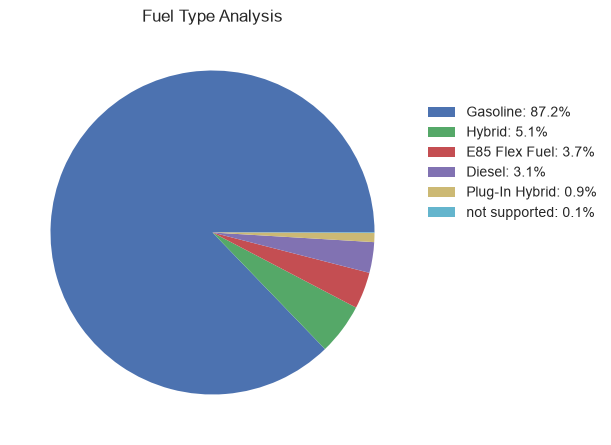

In [54]:
percentages = fuel_analysis / fuel_analysis.sum() * 100
labels = []
for fuel, perc in zip(fuel_analysis.index, percentages):
    labels.append(f'{fuel}: {perc:1.1f}%')
plt.figure(figsize=(12, 5))
plt.pie(fuel_analysis.values)
plt.title('Fuel Type Analysis')
plt.legend(labels=labels, bbox_to_anchor=(1, 0.5), loc='lower left')
plt.show()

Gasoline is the most common fuel type, representing 87.2% of the dataset, while hybrid, diesel, and plug-in hybrid vehicles constitute only a small proportion of the data.

In [72]:
transmission_analysis = data.groupby('transmission').transmission.count().sort_values(ascending=False)

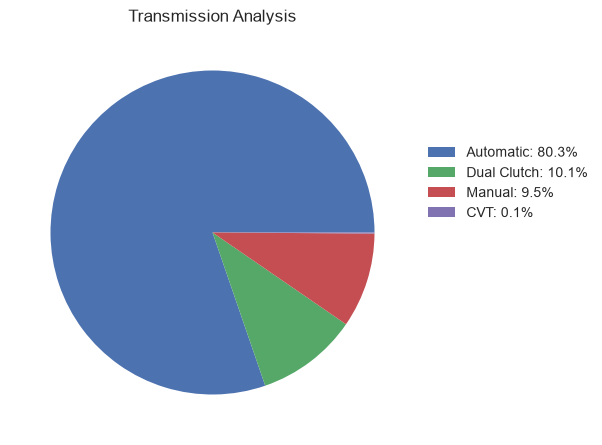

In [73]:
percentages = transmission_analysis / transmission_analysis.sum() * 100
labels = []
for fuel, perc in zip(transmission_analysis.index, percentages):
    labels.append(f'{fuel}: {perc:1.1f}%')
plt.figure(figsize=(12, 5))
plt.pie(transmission_analysis.values)
plt.title('Transmission Analysis')
plt.legend(labels=labels, bbox_to_anchor=(1, 0.5), loc='lower left')
plt.show()

In [60]:
data[data.transmission == 'Automatic'].price.median()

np.float64(32000.0)

In [68]:
data.groupby('transmission').price.median().sort_values(ascending=False)

transmission
Dual Clutch    34000.0
Automatic      32000.0
CVT            29998.0
Manual         23625.0
Name: price, dtype: float64

In [69]:
data.groupby('transmission').milage.median().sort_values(ascending=False)

transmission
Manual         62581.0
Automatic      52000.0
Dual Clutch    51000.0
CVT            20892.0
Name: milage, dtype: float64

In [71]:
data.groupby('transmission').model_year.median().sort_values(ascending=False)

transmission
CVT            2021.5
Automatic      2018.0
Dual Clutch    2016.0
Manual         2010.0
Name: model_year, dtype: float64

Automatic transmission dominates the dataset. Despite not having the highest median price or model year, automatic vehicles consistently rank among the top transmission types in terms of price, mileage, and model year, suggesting that they represent a significant segment of the used car market in this dataset.

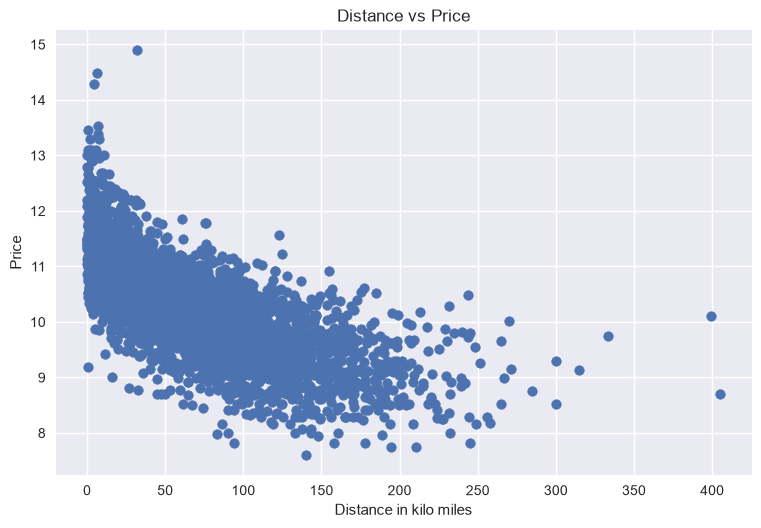

In [87]:
sorted_data = data.sort_values(by='milage')
plt.scatter(sorted_data.milage.values / 1000,
            np.log1p(sorted_data.price.values))
plt.title('Distance vs Price')
plt.xlabel('Distance in kilo miles')
plt.ylabel('Price')
plt.show()

In [88]:
data[['milage', 'price']].corr()

,milage,price
milage,1.000000,-0.305528
price,-0.305528,1.000000


There is a moderate negative correlation (-0.305) between mileage and price, indicating that vehicles with higher mileage tend to have lower prices.

In [98]:
data.accident.value_counts() / data.shape[0] * 100

accident
At least 1 accident or damage reported    24.594662
Name: count, dtype: float64

In [94]:
data[data.accident == 'At least 1 accident or damage reported'].model_year.describe()

count     986.000000
mean     2013.436105
std         5.670878
min      1993.000000
25%      2010.000000
50%      2015.000000
75%      2018.000000
max      2023.000000
Name: model_year, dtype: float64

In [97]:
data[(data.accident == 'At least 1 accident or damage reported')].brand.value_counts()

brand
Ford             100
Bmw               84
Mercedes-Benz     75
Chevrolet         73
Lexus             58
Toyota            53
Audi              52
Porsche           37
Nissan            37
Cadillac          34
Gmc               34
Dodge             32
Jeep              28
Subaru            24
Ram               24
Hyundai           23
Mazda             19
Honda             18
Land              17
Infiniti          17
Acura             17
Kia               15
Lincoln           14
Volkswagen        13
Jaguar            11
Buick             11
Volvo              9
Chrysler           8
Hummer             8
Mitsubishi         7
Maserati           5
Mini               4
Tesla              4
Pontiac            4
Scion              3
Bentley            3
Aston              2
Fiat               2
Alfa               1
Ferrari            1
Genesis            1
Mercury            1
Rolls-Royce        1
Saturn             1
Suzuki             1
Name: count, dtype: int64

Approximately 24.6% of vehicles have at least one reported accident, and 75% of them were manufactured before 2018. Ford accounts for the largest number of vehicles with reported accidents in the dataset. However, further analysis is required to determine whether this is due to Ford being the most frequent brand or because Ford vehicles have a relatively higher accident rate.

In [104]:
unique_brands = data.brand.unique()
percentages = []
for brand in unique_brands:
    percentages.append(data[(data.brand == brand) & (data.accident == 'At least 1 accident or damage reported')].shape[0] / data[data.brand == brand].shape[0] * 100)
brand_accident = pd.Series(percentages, index=unique_brands).sort_values(ascending=False)
brand_accident


Suzuki           100.000000
Hummer            50.000000
Scion             50.000000
Fiat              40.000000
Subaru            37.500000
Gmc               37.362637
Buick             36.666667
Lexus             35.582822
Dodge             35.555556
Mitsubishi        35.000000
Mercury           33.333333
Hyundai           31.944444
Nissan            31.896552
Cadillac          31.775701
Mazda             29.687500
Infiniti          28.813559
Chrysler          28.571429
Honda             28.571429
Lincoln           26.923077
Pontiac           26.666667
Toyota            26.633166
Acura             26.562500
Ram               26.373626
Audi              26.000000
Ford              25.906736
Chevrolet         25.000000
Mercedes-Benz     23.809524
Volvo             23.684211
Jaguar            23.404255
Bmw               22.400000
Aston             22.222222
Volkswagen        22.033898
Saturn            20.000000
Kia               19.736842
Jeep              19.580420
Porsche           18

Suzuki has the highest accident rate among brands with very few observations.

Ford isn't necessarily more accident-prone than other brands

Ford appears frequently in accident records primarily because it is the most common brand in the dataset.

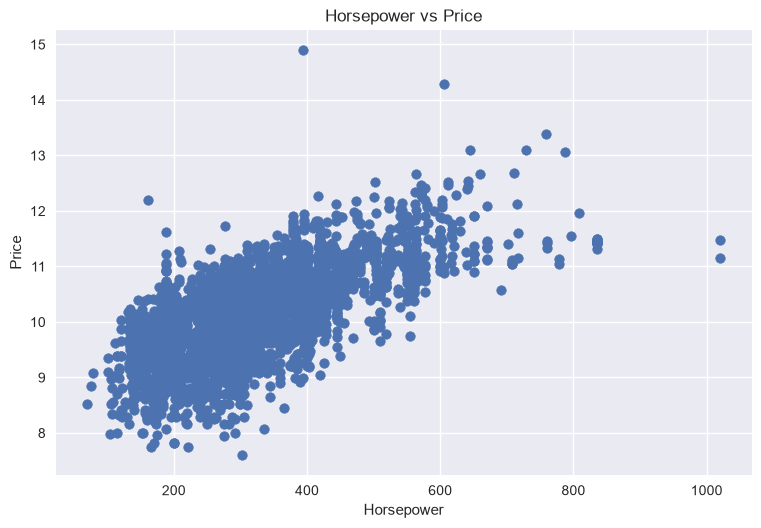

In [111]:
HP_analysis = data.sort_values(by='HP')

plt.scatter(HP_analysis.HP.values, np.log1p(HP_analysis.price.values))
plt.xlabel('Horsepower')
plt.ylabel('Price')
plt.title('Horsepower vs Price')
plt.show()

In [110]:
data[['HP', 'price']].corr()

,HP,price
HP,1.000000,0.354033
price,0.354033,1.000000


Horsepower exhibits a moderate positive correlation with vehicle price.

There is a positive relationship between horsepower and vehicle price. Cars with higher horsepower tend to be more expensive than those with lower horsepower.

In [112]:
data.columns

Index(['brand', 'model', 'model_year', 'milage', 'fuel_type', 'engine',
       'transmission', 'ext_col', 'int_col', 'accident', 'clean_title',
       'price', 'HP', 'engine_size', 'n_cylinders'],
      dtype='str')

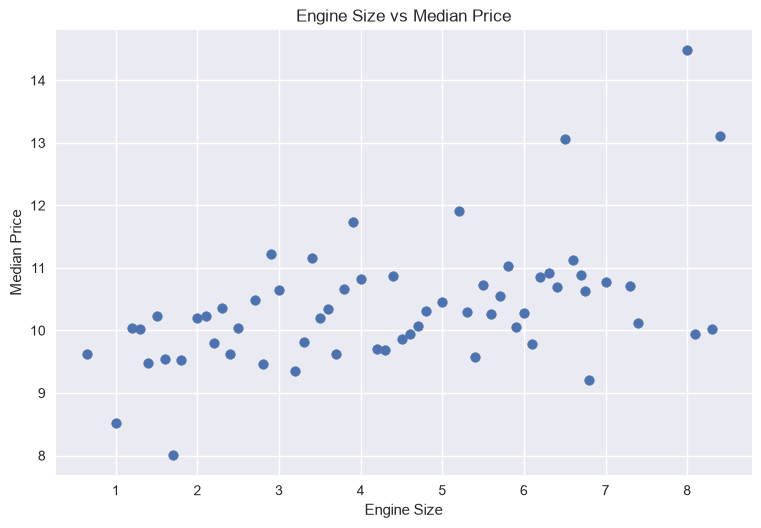

In [123]:
engine_size_analysis = data.groupby('engine_size').price.median().sort_index()

plt.scatter(engine_size_analysis.index, np.log1p(engine_size_analysis.values))
plt.xlabel('Engine Size')
plt.ylabel('Median Price')
plt.title('Engine Size vs Median Price')
plt.show()

In [116]:
data[['engine_size', 'price']].corr()

,engine_size,price
engine_size,1.000000,0.177507
price,0.177507,1.000000


Vehicles with larger engine sizes tend to have higher median prices, although the relationship appears relatively weak.

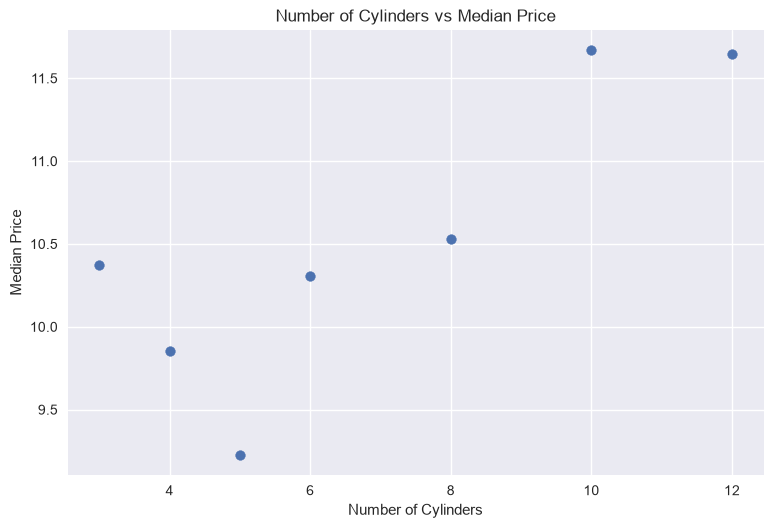

In [125]:
n_cylinder_analysis = data.groupby('n_cylinders').price.median().sort_index()

plt.scatter(n_cylinder_analysis.index, np.log1p(n_cylinder_analysis.values))
plt.xlabel('Number of Cylinders')
plt.ylabel('Median Price')
plt.title('Number of Cylinders vs Median Price')
plt.show()

In [126]:
data[['n_cylinders', 'price']].corr()

,n_cylinders,price
n_cylinders,1.000000,0.264967
price,0.264967,1.000000


Vehicles with a larger number of cylinders tend to have higher median prices. However, the relationship is not strictly linear, suggesting that the number of cylinders alone is not sufficient to explain vehicle prices.